Entorno y dependencias

In [ ]:
!pip install -q uv
!rm -rf /content/airflow_venv
!uv venv --python 3.12 /content/airflow_venv
!uv pip install --python /content/airflow_venv/bin/python "apache-airflow==2.11.2" --constraint "https://raw.githubusercontent.com/apache/airflow/constraints-2.11.2/constraints-3.12.txt"
!uv pip install --python /content/airflow_venv/bin/python numpy pandas pandera "typing-extensions>=4.15"

import os
from google.colab import drive

drive.mount('/content/drive')



# Usar el entorno aislado de Airflow en las siguientes celdas
os.environ["PATH"] = "/content/airflow_venv/bin:" + os.environ["PATH"]
os.environ["VIRTUAL_ENV"] = "/content/airflow_venv"
os.environ['AIRFLOW_HOME'] = '/content/airflow'
os.environ['AIRFLOW__CORE__LOAD_EXAMPLES'] = 'False' # Apagamos los ejemplos



# 2. Inicialización de base de datos y carpetas
!airflow db migrate > /dev/null 2>&1
!mkdir -p /content/airflow/dags

print("✅ Entorno de Airflow listo.")

Automatización

In [2]:
%%writefile /content/airflow/dags/dag_ramificado_grammy_spotify.py
import sqlite3 as sq3
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import pandera.pandas as pa
from pandera import Check

from airflow import DAG
from airflow.operators.python import PythonOperator, BranchPythonOperator

# ----------------------------------------------------------------------------
# Rutas (absolutas). Drive debe estar montado ANTES de arrancar Airflow.
# ----------------------------------------------------------------------------
ruta_base = "/content/drive/My Drive/"
ruta_db_grmmy = ruta_base + "grammys_db.sqlite"

ruta_spotify = "/content/datasetSpotifi.csv"
ruta_grammy = "/content/the_grammy_awards.csv"

# Archivo temporal donde "combinacion_tablas" deja su resultado para las tareas siguientes
ruta_intermedio = "/content/combinado_tmp.pkl"
# CSV final
ruta_csv_final = ruta_base + "grammys_spotify.csv"

COLUMNA_CLAVE = "nominee"   # la columna que no puede traer nulos

LST_PBLSHD_AT = ['2020-05-19T05:10:28-07:00', '2018-12-06T23:48:49-08:00',
                 '2018-05-22T03:08:24-07:00', '2017-11-28T00:03:45-08:00']
LST_APDTD_AT = ['2020-05-19T05:10:28-07:00', '2019-09-10T01:06:11-07:00',
                '2019-09-10T01:09:02-07:00', '2020-09-01T12:16:40-07:00',
                '2019-09-10T01:06:59-07:00', '2019-09-10T01:07:37-07:00',
                '2019-09-10T01:08:19-07:00', '2019-09-10T01:11:09-07:00',
                '2017-11-28T00:03:45-08:00', '2019-09-10T01:11:48-07:00']

# Variables numéricas de Spotify que se promedian al agregar
COLS_NUM = ["popularity", "duration_ms", "danceability", "energy", "loudness",
            "speechiness", "acousticness", "instrumentalness", "liveness",
            "valence", "tempo"]


# ----------------------------------------------------------------------------
# Utilidades
# ----------------------------------------------------------------------------
def esquema_grammys():
    """Un único esquema, usado por la validación inicial y la de silver."""
    return pa.DataFrameSchema({
        "year": pa.Column(int, Check.in_range(1958, 2019), nullable=False),
        "title": pa.Column(str, nullable=False),
        "published_at": pa.Column(str, Check.isin(LST_PBLSHD_AT), nullable=False),
        "updated_at": pa.Column(str, Check.isin(LST_APDTD_AT), nullable=False),
        "category": pa.Column(str, nullable=False),
        "nominee": pa.Column(str, nullable=False),
        "artist": pa.Column(str, nullable=True),
        "workers": pa.Column(str, nullable=True),
        "img": pa.Column(str, nullable=True),
        "winner": pa.Column(int, nullable=False),
    })


def leer_tabla(nombre):
    conn = sq3.connect(ruta_db_grmmy)
    try:
        return pd.read_sql_query(f"SELECT * FROM {nombre}", conn)
    finally:
        conn.close()


def _norm(s):
    """Minúsculas, sin espacios sobrantes y sin nulos (NaN -> '')."""
    return s.fillna("").astype(str).str.lower().str.strip()


# ----------------------------------------------------------------------------
# Tareas de extracción
# ----------------------------------------------------------------------------
def extrccn_spotify():
    sptfy = pd.read_csv(ruta_spotify)
    print(f"Spotify leído: {len(sptfy)} filas, {len(sptfy.columns)} columnas")
    return ruta_spotify          # solo la ruta, no el DataFrame


def extrccn_grammy():
    conn = sq3.connect(ruta_db_grmmy)
    conn.executescript("""
        DROP TABLE IF EXISTS grammys;
        CREATE TABLE grammys (
            year INTEGER NOT NULL,
            title TEXT NOT NULL,
            published_at TEXT NOT NULL,
            updated_at TEXT NOT NULL,
            category TEXT NOT NULL,
            nominee TEXT,
            artist TEXT,
            workers TEXT,
            img TEXT,
            winner INTEGER NOT NULL
        );

        DROP TABLE IF EXISTS grammys_silver;
        CREATE TABLE grammys_silver (
            year INTEGER NOT NULL,
            title TEXT NOT NULL,
            published_at TEXT NOT NULL,
            updated_at TEXT NOT NULL,
            category TEXT NOT NULL,
            nominee TEXT NOT NULL,
            artist TEXT,
            workers TEXT,
            img TEXT,
            winner INTEGER NOT NULL
        );
    """)
    grmmy = pd.read_csv(ruta_grammy)
    grmmy.to_sql("grammys", conn, if_exists="append", index=False)
    conn.commit()
    conn.close()
    print(f"Tabla grammys cargada: {len(grmmy)} filas")


# ----------------------------------------------------------------------------
# Validación (BRANCH) y transformación de Grammy
# ----------------------------------------------------------------------------
def validacion_grmmys():
    """Única tarea que ramifica: devuelve el task_id al que se salta."""
    df = leer_tabla("grammys")
    try:
        esquema_grammys().validate(df, lazy=True)
        print("Validación exitosa")
        return "combinacion_tablas"
    except pa.errors.SchemaErrors as exc:
        fallos = exc.failure_cases
        print("La validación encontró problemas:\n")
        print(fallos)
        # solo transformamos si el problema es exclusivamente la columna clave
        if set(fallos["column"].dropna()) <= {COLUMNA_CLAVE}:
            return "trnsform_grammy_task"
        raise                    # otros problemas: dropna no los arregla


def trnsform_grmmys():
    df = leer_tabla("grammys")
    df_clean = df.dropna(subset=[COLUMNA_CLAVE]).copy()
    print(f"Filas eliminadas por nulos en {COLUMNA_CLAVE}: {len(df) - len(df_clean)}")

    conn = sq3.connect(ruta_db_grmmy)
    conn.execute("DELETE FROM grammys_silver")      # evita duplicados si se reintenta
    df_clean.to_sql("grammys_silver", conn, if_exists="append", index=False)
    conn.commit()
    conn.close()
    print("Tabla grammys_silver lista")
    return "grammys_silver"      # nombre de tabla por XCom


def validacion_grmmys_silver():
    """Tarea normal (NO branch): si falla, lanza excepción y queda en failed."""
    df = leer_tabla("grammys_silver")
    esquema_grammys().validate(df, lazy=True)
    print("Validación de silver exitosa")


# ----------------------------------------------------------------------------
# Transformación de Spotify y combinación
# ----------------------------------------------------------------------------
def limpiar_spotify(ruta):
    """Una fila por pista, sin nulos en las columnas de nombre."""
    s = pd.read_csv(ruta).drop(columns=["Unnamed: 0"], errors="ignore")

    # Una misma pista aparece repetida una vez por género: guardamos los géneros
    generos = (s.groupby("track_id")["track_genre"]
                .agg(lambda x: ";".join(sorted(set(x)))))
    s = s.drop_duplicates(subset="track_id").drop(columns="track_genre")
    s["generos"] = s["track_id"].map(generos)

    s = s.dropna(subset=["artists", "album_name", "track_name"])
    # Spotify separa artistas con ";" y pone primero al principal
    s["artista_principal"] = _norm(s["artists"].str.split(";").str[0])
    return s


def agregar_spotify(s, col_nombre, prefijo):
    """Reduce Spotify a UNA fila por (nombre, artista principal)."""
    s = s.assign(key=_norm(s[col_nombre]))
    agg = {c: (c, "mean") for c in COLS_NUM}
    agg["n_pistas"] = ("track_id", "nunique")
    agg["generos"] = ("generos",
                      lambda x: ";".join(sorted(set(";".join(x).split(";")))))
    out = s.groupby(["key", "artista_principal"], as_index=False).agg(**agg)

    renombrar = {c: f"{prefijo}_{c}" for c in out.columns
                 if c not in ("key", "artista_principal")}
    renombrar["artista_principal"] = f"{prefijo}_artista"
    return out.rename(columns=renombrar)


def mejor_coincidencia(grmmy, spt_agg, prefijo):
    """Para cada nominación elige UNA fila de Spotify.

    Une por nombre (puede dar varios candidatos: 'Bad Guy' lo tienen decenas
    de artistas) y exige que el artista coincida. Solo si la nominación no
    trae artista (38 % de los casos) no hay forma de verificar: se acepta el
    candidato más popular, marcado como 'nombre_sin_verificar'.
    """
    col_art = f"{prefijo}_artista"
    cand = grmmy[["grammy_id", "nominee_key", "artist_key"]].merge(
        spt_agg, left_on="nominee_key", right_on="key", how="inner")

    cand["artista_ok"] = [
        bool(ga) and (sa in ga or ga in sa)
        for ga, sa in zip(cand["artist_key"], cand[col_art])
    ]
    # Si Grammy trae artista y no coincide, es otra obra con el mismo nombre
    cand = cand[cand["artista_ok"] | (cand["artist_key"] == "")]
    cand = cand.sort_values(
        ["grammy_id", "artista_ok", f"{prefijo}_popularity"],
        ascending=[True, False, False])
    mejor = cand.drop_duplicates("grammy_id").copy()

    mejor[f"{prefijo}_coincidencia"] = np.where(
        mejor["artista_ok"], "nombre+artista", "nombre_sin_verificar")
    return mejor.drop(columns=["nominee_key", "artist_key", "key", "artista_ok"])


def combinacion_tablas(ti):
    # tabla limpia si hubo transformación; si no, la original
    tabla = ti.xcom_pull(task_ids="trnsform_grammy_task") or "grammys"
    ruta = ti.xcom_pull(task_ids="extrccn_spotify") or ruta_spotify
    print(f"Combinando usando la tabla: {tabla}")

    grmmy = leer_tabla(tabla).reset_index(drop=True)
    grmmy["grammy_id"] = grmmy.index
    grmmy["nominee_key"] = _norm(grmmy["nominee"])
    grmmy["artist_key"] = _norm(grmmy["artist"])

    s = limpiar_spotify(ruta)

    # El nominado puede ser un álbum o una canción según la categoría,
    # así que se busca en ambos niveles.
    alb = mejor_coincidencia(grmmy, agregar_spotify(s, "album_name", "album"), "album")
    trk = mejor_coincidencia(grmmy, agregar_spotify(s, "track_name", "track"), "track")

    combinado = (
        grmmy.merge(alb, on="grammy_id", how="left", validate="one_to_one")
             .merge(trk, on="grammy_id", how="left", validate="one_to_one")
             .drop(columns=["nominee_key", "artist_key"])
    )

    # Red de seguridad: una fila por nominación, ni una más
    if len(combinado) != len(grmmy):
        raise ValueError(f"Se duplicaron filas: {len(grmmy)} -> {len(combinado)}")

    print(f"Nominaciones: {len(grmmy)}")
    print(f"Con coincidencia de álbum: {combinado['album_coincidencia'].notna().sum()}")
    print(f"Con coincidencia de pista: {combinado['track_coincidencia'].notna().sum()}")

    combinado.to_pickle(ruta_intermedio)       # las tareas siguientes lo leen de aquí
    print(f"Resultado guardado temporalmente: {len(combinado)} filas, {len(combinado.columns)} columnas")
    return ruta_intermedio


# ----------------------------------------------------------------------------
# Carga final: SQLite y CSV (tareas separadas)
# ----------------------------------------------------------------------------
def carga_sqlite():
    combinado = pd.read_pickle(ruta_intermedio)
    conn = sq3.connect(ruta_db_grmmy)
    combinado.to_sql("grammys_spotify", conn, if_exists="replace", index=False)
    conn.close()
    print(f"Tabla grammys_spotify cargada en SQLite: {len(combinado)} filas")


def exportar_csv():
    combinado = pd.read_pickle(ruta_intermedio)
    combinado.to_csv(ruta_csv_final, index=False)
    print(f"CSV creado en {ruta_csv_final}: {len(combinado)} filas")


# ----------------------------------------------------------------------------
# DAG
# ----------------------------------------------------------------------------
default_args = {
    'owner': 'carlos_cordoba',
    'depends_on_past': False,
    'retries': 1,
    'retry_delay': timedelta(minutes=1),
}

with DAG(
    'etl_con_flujo_grammys_spotify',
    default_args=default_args,
    description='DAG con la ejecución de tareas para los datasets grammy y spotify',
    schedule='@daily',               # schedule_interval en Airflow < 2.4
    start_date=datetime(2023, 1, 1),
    catchup=False,
    tags=['Grammy', 'Spotify'],
) as dag:

    t_extr_spotify = PythonOperator(
        task_id="extrccn_spotify",
        python_callable=extrccn_spotify
        )

    t_extr_grammy = PythonOperator(
        task_id="extrccn_grammy",
        python_callable=extrccn_grammy
        )

    t_validar = BranchPythonOperator(
        task_id="validacion_grmmys",
        python_callable=validacion_grmmys
        )

    t_transf = PythonOperator(
        task_id="trnsform_grammy_task",
        python_callable=trnsform_grmmys
        )

    t_val_silver = PythonOperator(
        task_id="validacion_grmmys_silver",
        python_callable=validacion_grmmys_silver,
        retries=0
        )   # validación determinista: reintentar no cambia nada

    t_combinar = PythonOperator(
        task_id="combinacion_tablas",
        python_callable=combinacion_tablas,
        trigger_rule="none_failed_min_one_success",   # imprescindible por la rama saltada
    )

    t_carga_sqlite = PythonOperator(
        task_id="carga_sqlite",
        python_callable=carga_sqlite
        )

    t_exportar_csv = PythonOperator(
        task_id="exportar_csv",
        python_callable=exportar_csv
        )

    t_extr_grammy >> t_validar
    t_validar >> [t_combinar, t_transf]
    t_transf >> t_val_silver >> t_combinar
    t_extr_spotify >> t_combinar
    t_combinar >> [t_carga_sqlite, t_exportar_csv]

Writing /content/airflow/dags/dag_ramificado_grammy_spotify.py


Pruebas

In [ ]:
!airflow dags test etl_con_flujo_grammys_spotify 2023-01-01

In [9]:
# Le decimos a Airflow que mueva su servidor web al puerto 8081
os.system("fuser -k 8081/tcp > /dev/null 2>&1")
os.environ['AIRFLOW__WEBSERVER__WEB_SERVER_PORT'] = '8081'

In [10]:
import os
import time
import urllib.request
import subprocess
import re

# 0. Limpiar procesos huérfanos de intentos anteriores
os.system("pkill -9 -f airflow")
os.system("pkill -9 -f cloudflared")
time.sleep(2)

env = os.environ.copy()
env['AIRFLOW_HOME'] = '/content/airflow'

# 1. Crear usuario administrador
print("1/3 Configurando credenciales de usuario...")
subprocess.run(['airflow',
                'users',
                'create',
                '--username',
                'admin',
                '--password',
                'admin',
                '--firstname',
                'Estudiante',
                '--lastname',
                'Colab',
                '--role',
                'Admin',
                '--email',
                'admin@ejemplo.com'], env=env, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

# 2. Iniciar Airflow en segundo plano
print("2/3 Arrancando orquestador (puede tardar 30-40 segundos)...")
log_file = open('/content/airflow_server.log', 'w')
subprocess.Popen(['airflow', 'standalone'], env=env, stdout=log_file, stderr=subprocess.STDOUT)

# Espera inteligente con timeout (máximo 60 segundos)
listo = False
for _ in range(30):
    try:
        if urllib.request.urlopen('http://localhost:8081').getcode() == 200:
            listo = True
            break
    except:
        time.sleep(2)

if not listo:
    print("\n❌ Error: Airflow no pudo iniciar a tiempo. Aquí están las últimas líneas del log para diagnosticar:")
    os.system("tail -n 20 /content/airflow_server.log")
else:
    print("✅ Servidor Web OK.\n3/3 Generando túnel público de Cloudflare...")

    # 3. Usar Cloudflare Tunnels
    os.system("wget -q -nc https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /content/cloudflared")
    os.system("chmod +x /content/cloudflared")
    os.system("/content/cloudflared tunnel --url http://localhost:8081 > /content/tunnel.log 2>&1 &")

    time.sleep(6) # Dar tiempo a que asigne la URL

    with open('/content/tunnel.log', 'r') as f:
        log_content = f.read()
        urls = re.findall(r'https://[a-zA-Z0-9-]+\.trycloudflare\.com', log_content)
        if urls:
            print("\n" + "="*60)
            print("🚀 ACCESO A LA INTERFAZ DE AIRFLOW 🚀")
            print("="*60)
            print(f"Haz clic en el siguiente enlace:\n{urls[0]}")
            print("\nCredenciales:")
            print("Usuario: admin")
            print("Password: admin")
            print("="*60)
        else:
            print("\n❌ Error generando la URL. Log de Cloudflare:")
            os.system("cat /content/tunnel.log")


1/3 Configurando credenciales de usuario...
2/3 Arrancando orquestador (puede tardar 30-40 segundos)...
✅ Servidor Web OK.
3/3 Generando túnel público de Cloudflare...

🚀 ACCESO A LA INTERFAZ DE AIRFLOW 🚀
Haz clic en el siguiente enlace:
https://size-configuration-vsnet-limits.trycloudflare.com

Credenciales:
Usuario: admin
Password: admin


Consultas

In [20]:
import pandas as pd
from datetime import datetime, timedelta
import random
import sqlite3 as sq3
import matplotlib.pyplot as plt

In [18]:
ruta_base = "/content/drive/My Drive/"
ruta_db_grmmy = ruta_base + "grammys_db.sqlite"

# Nos conectamos a la base de datos
conn = sq3.connect(ruta_db_grmmy)

# Obtenemos el listado de tablas en SQLite usando pandas para visualizarlo mejor
tablas_df = pd.read_sql_query("""
    SELECT name FROM sqlite_master
    WHERE type='table';
""", conn)

# Mostramos las tablas
display(tablas_df)

conn.close()

,name
0,grammys
1,grammys_silver
2,grammys_spotify


In [21]:
RUTA_DB = "/content/drive/My Drive/grammys_db.sqlite"
RUTA_SPOTIFY = "/content/datasetSpotifi.csv"      # solo para tener un promedio de referencia

conn = sq3.connect(RUTA_DB)
df = pd.read_sql_query("SELECT * FROM grammys_spotify", conn)
conn.close()

df["decada"] = (df["year"] // 10) * 10

# Una nominación está "verificada" si el nombre Y el artista coinciden con Spotify
ok_album = df["album_coincidencia"] == "nombre+artista"
ok_pista = df["track_coincidencia"] == "nombre+artista"
df["verificada"] = ok_album | ok_pista

print(f"{len(df)} nominaciones, {df['year'].min()}-{df['year'].max()}, {df['category'].nunique()} categorías")

4804 nominaciones, 1958-2019, 633 categorías


Verificada (nombre + artista)     7.5 %
Solo nombre (sin verificar)       5.9 %
Sin coincidencia en Spotify      86.6 %
dtype: object


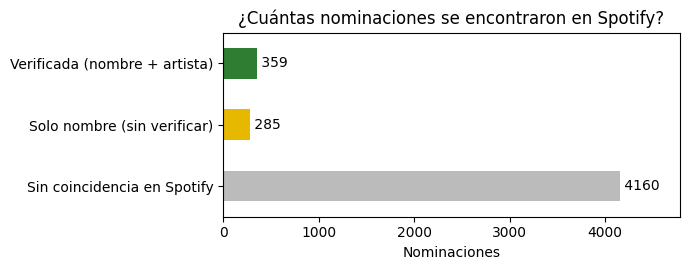

In [22]:
con_algo = df["album_coincidencia"].notna() | df["track_coincidencia"].notna()

cobertura = pd.Series({
    "Verificada (nombre + artista)": df["verificada"].sum(),
    "Solo nombre (sin verificar)": (con_algo & ~df["verificada"]).sum(),
    "Sin coincidencia en Spotify": (~con_algo).sum(),
})

print((cobertura / len(df) * 100).round(1).astype(str) + " %")

ax = cobertura[::-1].plot.barh(color=["#bbbbbb", "#e6b800", "#2e7d32"], figsize=(7, 2.8))
ax.set_title("¿Cuántas nominaciones se encontraron en Spotify?")
ax.set_xlabel("Nominaciones")
ax.set_xlim(0, cobertura.max() * 1.15)      # espacio para las etiquetas
for i, v in enumerate(cobertura[::-1]):
    ax.text(v, i, f" {v}", va="center")
plt.tight_layout()
plt.show()

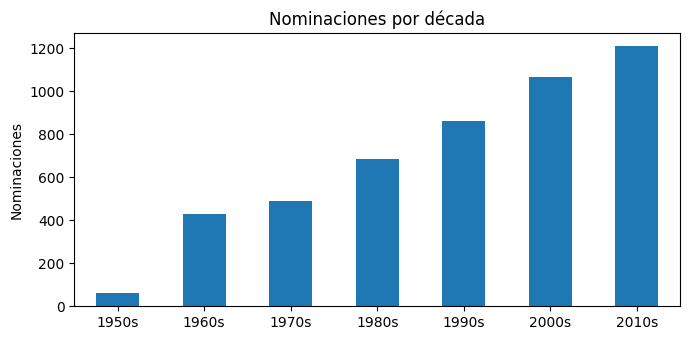

In [23]:
por_decada = df.groupby("decada").size()
por_decada.index = [f"{d}s" for d in por_decada.index]

ax = por_decada.plot.bar(color="#1f77b4", figsize=(7, 3.5), rot=0)
ax.set_title("Nominaciones por década")
ax.set_ylabel("Nominaciones")
plt.tight_layout()
plt.show()

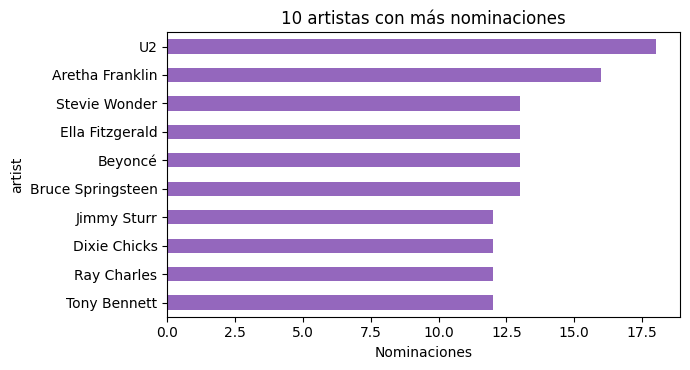

In [24]:
top = (df["artist"].value_counts()
         .drop("(Various Artists)", errors="ignore")   # no es un artista real
         .head(10))

ax = top[::-1].plot.barh(color="#9467bd", figsize=(7, 3.8))
ax.set_title("10 artistas con más nominaciones")
ax.set_xlabel("Nominaciones")
plt.tight_layout()
plt.show()

Obras verificadas analizadas: 359

              Obras nominadas  Todo Spotify
popularity              55.63         33.20
danceability             0.59          0.56
energy                   0.60          0.63
valence                  0.50          0.47
acousticness             0.30          0.33


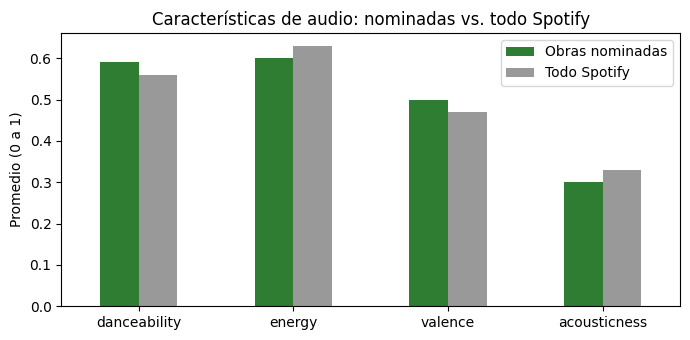

In [25]:
# Perfil de audio de las obras verificadas: si la pista coincide se usa la pista, si no, el álbum
v = df[df["verificada"]].copy()
metricas = ["popularity", "danceability", "energy", "valence", "acousticness"]
for m in metricas:
    v[m] = v[f"track_{m}"].where(ok_pista[v.index], v[f"album_{m}"])

# Referencia: promedio de TODO el catálogo de Spotify
spotify = pd.read_csv(RUTA_SPOTIFY).drop_duplicates("track_id")

comparacion = pd.DataFrame({
    "Obras nominadas": v[metricas].mean(),
    "Todo Spotify": spotify[metricas].mean(),
}).round(2)
print(f"Obras verificadas analizadas: {len(v)}\n")
print(comparacion)

audio = comparacion.drop("popularity")
ax = audio.plot.bar(figsize=(7, 3.5), rot=0, color=["#2e7d32", "#999999"])
ax.set_title("Características de audio: nominadas vs. todo Spotify")
ax.set_ylabel("Promedio (0 a 1)")
plt.tight_layout()
plt.show()

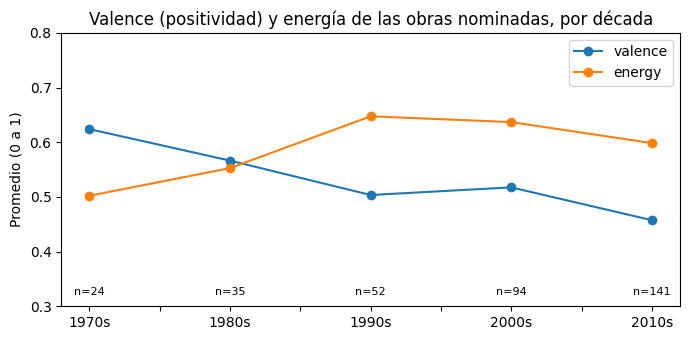

       valence  energy    n
1970s     0.62    0.50   24
1980s     0.57    0.55   35
1990s     0.50    0.65   52
2000s     0.52    0.64   94
2010s     0.46    0.60  141


In [26]:
# Evolución del tono de las obras nominadas. Solo décadas con muestra razonable (n >= 20)
tend = v.groupby("decada").agg(valence=("valence", "mean"),
                               energy=("energy", "mean"),
                               n=("valence", "size"))
tend = tend[tend["n"] >= 20]
tend.index = [f"{d}s" for d in tend.index]

ax = tend[["valence", "energy"]].plot(marker="o", figsize=(7, 3.5))
ax.set_title("Valence (positividad) y energía de las obras nominadas, por década")
ax.set_ylabel("Promedio (0 a 1)")
ax.set_ylim(0.3, 0.8)
for i, n in enumerate(tend["n"]):
    ax.annotate(f"n={n}", (i, 0.32), ha="center", fontsize=8)
plt.tight_layout()
plt.show()
print(tend.round(2))